In [49]:
#Required Libaries
import time
import matplotlib.pyplot as plt
import numpy as np
import glob

In [ ]:
#Creates an array of size n
def createArray(n):
    return list((np.random.randint(100, size = n)))

#Creating files for test data to read to have consistent test data
def createTestData():
    testData = []
    for i in range(1, 100):
        with open(f"./Data/Data{i}.txt", "w") as f:
            testData = createArray(i)
            for i in range(len(testData)):
                if(i!=len(testData)-1):
                    f.write(f"{(testData[i])},")
                else:
                    f.write(f"{(testData[i])}")

def readTestData():
    testData = []
    #Read in from all the files in our data folder
    for f in glob.glob("Data/Data*.txt"):
        with open(f, "r") as inputFile:
            #We ensure that the file being read in is atleast 1 dimensional before casting it to a list of integers
            testArray = list(np.atleast_1d(np.loadtxt(inputFile, dtype=int, delimiter=",")))
            testData.append(testArray)
    return testData

[[99], [64, 77, 52, 90, 15, 24, 92, 22, 60, 87], [69, 61, 84, 35, 57, 81, 61, 87, 24, 38, 71], [42, 75, 66, 45, 76, 99, 83, 97, 19, 22, 90, 95], [0, 22, 82, 70, 20, 66, 82, 55, 46, 78, 23, 54, 75], [36, 97, 25, 51, 0, 8, 88, 99, 78, 6, 42, 31, 1, 0], [26, 84, 95, 44, 55, 20, 81, 0, 6, 5, 0, 9, 99, 46, 95], [70, 91, 4, 2, 33, 91, 3, 40, 60, 39, 48, 98, 84, 18, 88, 3], [95, 25, 19, 71, 50, 36, 19, 10, 75, 57, 85, 64, 82, 43, 28, 51, 93], [71, 27, 74, 76, 12, 60, 21, 94, 42, 18, 65, 77, 81, 0, 74, 75, 81, 80], [87, 14, 3, 31, 49, 57, 34, 86, 47, 16, 74, 34, 18, 23, 88, 5, 22, 62, 98], [76, 3], [90, 20, 74, 55, 36, 76, 88, 91, 25, 42, 18, 69, 97, 98, 27, 54, 92, 7, 55, 89], [5, 20, 25, 12, 34, 53, 38, 19, 94, 83, 2, 51, 41, 9, 25, 11, 33, 1, 16, 19, 68], [96, 91, 61, 71, 20, 10, 25, 11, 62, 76, 12, 61, 17, 83, 59, 6, 45, 21, 33, 3, 8, 51], [3, 25, 60, 3, 66, 63, 5, 98, 57, 83, 90, 30, 98, 14, 40, 11, 28, 39, 50, 38, 59, 47, 36], [55, 46, 34, 97, 21, 31, 80, 85, 16, 12, 56, 18, 6, 53, 97, 4

In [51]:
#Insert sort implementation
def InsertionSort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i-1
        #If the checkeed element is greater than the key then we move those array elements to one position ahead
        while j>=0 and key<arr[j]: 
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key
    return arr

def TimeInsertionSort(arr):
    start = time.perf_counter()
    InsertionSort(arr)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [52]:
#Quick sort Implementation
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

def partition(arr, low, high):
    # Choosing the piviot 
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    swap(arr, i + 1, high)
    return i + 1

def QuickSort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        QuickSort(arr, low, pi - 1)
        QuickSort(arr, pi + 1, high)

def TimeQuickSort(arr):
    start = time.perf_counter()
    QuickSort(arr, 0, len(arr) -1)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1
 

In [53]:
def HybridSort(arr, k):
    if(len(arr) <= k):
        InsertionSort(arr)
    else:
        QuickSort(arr, 0, len(arr) -1)

def TimeHybridSort(arr, k):
    start = time.perf_counter()
    HybridSort(arr, k)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [54]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return arr == buffer_array

In [55]:
def testValue(k):
    testData = readTestData()
    insertionData = []
    quickData = []
    testDataLength = []
    hybridData = []
    #Collecting data for the time it takes to perform quick sort and insertion sort on the arrays created of different sizes.
    for testArray in testData:
        testDataLength.append(len(testArray))
        #We pass copies of the array so that each algorithm deals with the original unsorted array
        quickData.append(TimeQuickSort(testArray.copy()))
        insertionData.append(TimeInsertionSort(testArray.copy()))
    #If there is a -1 in the data, that means that the data for insertion or quick sort failed to pass the correctness test
    if(-1 in insertionData or -1 in quickData):
        print("One of the arrays were not sorted correctly.")
        return 1
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, insertionData, 1)
    c, d = np.polyfit(testDataLength, quickData, 1)
    xintersection = (d-b)/(a-c)
    xintersection = int(xintersection)
    for testArray in testData:
        hybridData.append(TimeHybridSort(testArray, k))
    e, f = np.polyfit(testDataLength, hybridData, 1)
    #ax.scatter(testDataLength, insertionData)
    #ax.scatter(testDataLength, quickData)
    ax.plot(testDataLength, a*testDataLength+b, label = "Insertion Sort")
    ax.plot(testDataLength, c*testDataLength+d, label = "Quick Sort")
    ax.plot(testDataLength, e*testDataLength+f, label = "Hybrid Sort")
    #Naming the graph and axes of the graph
    ax.set_title(f"Time to sort vs Size of array. K value for Hybrid Sort is {k}")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

<Figure size 640x480 with 0 Axes>

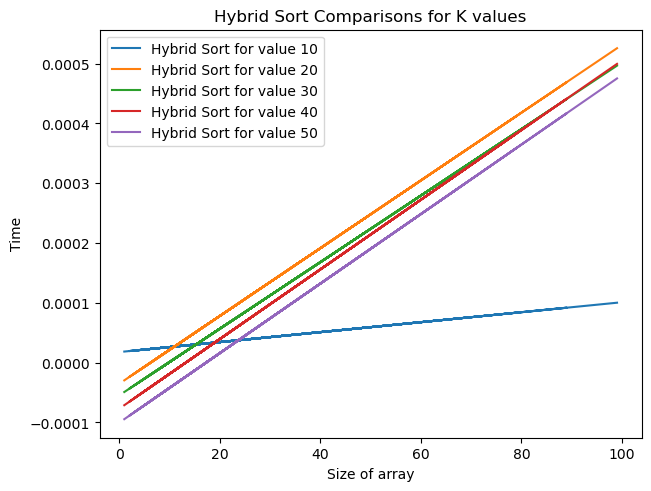

In [59]:
def main():
    testData = readTestData()
    testDataLength = []
    hybridData10 = []
    hybridData20 = []
    hybridData30 = []
    hybridData40 = []
    hybridData50 = []
    for testArray in testData:
        testDataLength.append(len(testArray))
        hybridData10.append(TimeHybridSort(testArray, 10))
        hybridData20.append(TimeHybridSort(testArray, 20))
        hybridData30.append(TimeHybridSort(testArray, 30))
        hybridData40.append(TimeHybridSort(testArray, 40))
        hybridData50.append(TimeHybridSort(testArray, 50))
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    testDataLength = np.array(testDataLength)
    a, b = np.polyfit(testDataLength, hybridData10, 1)
    c, d = np.polyfit(testDataLength, hybridData20, 1)
    e, f = np.polyfit(testDataLength, hybridData30, 1)
    g, h = np.polyfit(testDataLength, hybridData40, 1)
    i, j = np.polyfit(testDataLength, hybridData50, 1)
    ax.plot(testDataLength, a*testDataLength+b, label = "Hybrid Sort for value 10")
    ax.plot(testDataLength, c*testDataLength+d, label = "Hybrid Sort for value 20")
    ax.plot(testDataLength, e*testDataLength+f, label = "Hybrid Sort for value 30")
    ax.plot(testDataLength, g*testDataLength+h, label = "Hybrid Sort for value 40")
    ax.plot(testDataLength, i*testDataLength+j, label = "Hybrid Sort for value 50")
    #Naming the graph and axes of the graph
    ax.set_title(f"Hybrid Sort Comparisons for K values")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

main()